In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [3]:
df=pd.read_csv('student_performance.csv')
df.head()

,Student_ID,Name,Age,Program,Python,Mathematics,Statistics,Machine_Learning,Attendance
0,S001,Ali Khan,20,AI,85,78,92,88,95
1,S002,Sara Ahmed,21,AI,72,75,70,80,90
2,S003,Ahmed Raza,22,SE,90,88,91,93,96
3,S004,Fatima Noor,20,DS,65,70,68,72,85
4,S005,Usman Ali,21,AI,78,82,80,76,88


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Student_ID        20 non-null     object
 1   Name              20 non-null     object
 2   Age               20 non-null     int64 
 3   Program           20 non-null     object
 4   Python            20 non-null     int64 
 5   Mathematics       20 non-null     int64 
 6   Statistics        20 non-null     int64 
 7   Machine_Learning  20 non-null     int64 
 8   Attendance        20 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 1.5+ KB


Check missing values

In [5]:
df.isnull().sum()

Student_ID          0
Name                0
Age                 0
Program             0
Python              0
Mathematics         0
Statistics          0
Machine_Learning    0
Attendance          0
dtype: int64

avg_score column

In [6]:
SUBJECTS=["Python", "Mathematics", "Statistics", "Machine_Learning"]
df["Average_Score"] = df[SUBJECTS].mean(axis=1)
df[["Name"] + SUBJECTS + ["Average_Score"]].head()

,Name,Python,Mathematics,Statistics,Machine_Learning,Average_Score
0,Ali Khan,85,78,92,88,85.75
1,Sara Ahmed,72,75,70,80,74.25
2,Ahmed Raza,90,88,91,93,90.50
3,Fatima Noor,65,70,68,72,68.75
4,Usman Ali,78,82,80,76,79.00


Lebel encoding on categorical column

In [7]:
le = LabelEncoder()
df["Program_Encoded"] = le.fit_transform(df["Program"])
df[["Program", "Program_Encoded"]].drop_duplicates()

,Program,Program_Encoded
0,AI,0
2,SE,2
3,DS,1


Select features (x) and target (y)

In [8]:
X=df[["Age","Program_Encoded","Attendance"]]
Y=df["Average_Score"]

X.head()

,Age,Program_Encoded,Attendance
0,20,0,95
1,21,0,90
2,22,2,96
3,20,1,85
4,21,0,88


Train/Test Split

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape)

(16, 3) (4, 3)


Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled[:5]

array([[ 1.78017249,  1.28507921, -0.89399858],
       [ 0.83074716,  1.28507921,  1.56223995],
       [-0.11867817,  1.28507921,  1.41775533],
       [-1.06810349,  0.07559289, -0.46054472],
       [-0.11867817,  0.07559289, -1.18296782]])

Training Linear Regression Model

In [11]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_scaled,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predications on testing data

In [12]:
y_pred=model.predict(X_test_scaled)
y_pred

array([87.75913807, 96.70763736, 90.06007612, 81.26481457])

Comparison between the Actual and the Predicted 

In [13]:
comparison_df=pd.DataFrame({"Actual:":Y_test.values,"Predicted":y_pred})
comparison_df["Difference"]=comparison_df["Actual:"]-comparison_df["Predicted"]
comparison_df

,Actual:,Predicted,Difference
0,85.75,87.759138,-2.009138
1,97.25,96.707637,0.542363
2,89.50,90.060076,-0.560076
3,74.25,81.264815,-7.014815


Evaluation metrics

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 2.53
Mean Squared Error (MSE): 13.46
R² Score: 0.80


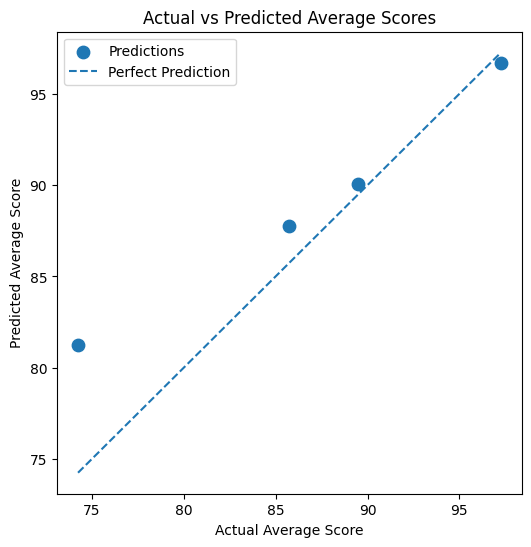

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(Y_test, y_pred, s=80, label="Predictions")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],  linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Average Score")
plt.ylabel("Predicted Average Score")
plt.title("Actual vs Predicted Average Scores")
plt.legend()
plt.show()